In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

# Robust path: works whether you run from project root or notebook/.
here = Path.cwd().resolve()
name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

candidates = [
    here / "data" / name,
    here.parent / "data" / name,
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        f"Dataset not found. Tried: {', '.join(str(p) for p in candidates)}"
    )

df = pd.read_csv(csv_path)

# Match script cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Insight

This dataset includes behavioral and demographic information of telecom customers. It is suitable for analyzing churn patterns and building predictive models to identify at-risk customers.


In [10]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-0.1, 12, 24, 48, 72, np.inf],
    labels=["0-1y", "1-2y", "2-4y", "4-6y", "6y+"],
    include_lowest=True,
)


### Insight

Converting tenure into grouped categories allows better segmentation of customers by lifecycle stage. This improves interpretability and helps detect churn patterns across early, mid, and long-term customers.


In [11]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   str     
 1   gender            7043 non-null   str     
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   str     
 4   Dependents        7043 non-null   str     
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   str     
 7   MultipleLines     7043 non-null   str     
 8   InternetService   7043 non-null   str     
 9   OnlineSecurity    7043 non-null   str     
 10  OnlineBackup      7043 non-null   str     
 11  DeviceProtection  7043 non-null   str     
 12  TechSupport       7043 non-null   str     
 13  StreamingTV       7043 non-null   str     
 14  StreamingMovies   7043 non-null   str     
 15  Contract          7043 non-null   str     
 16  PaperlessBilling  7043 non-null   s

### Insight

The dataset includes both categorical and numerical variables, requiring preprocessing steps such as encoding and type conversion. Minimal missing values suggest a high-quality dataset suitable for supervised learning tasks like churn prediction.


In [12]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
tenure_group        0
dtype: int64

### Insight

Missing values are minimal in the dataset, with `TotalCharges` being the only affected feature. These values were treated by type conversion and median imputation to maintain data integrity for machine learning models.


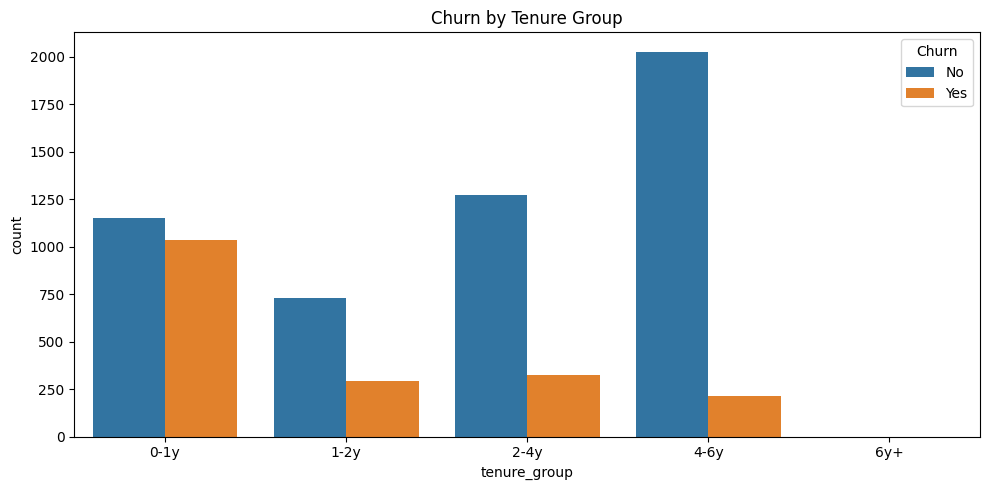

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
order = ["0-1y", "1-2y", "2-4y", "4-6y", "6y+"]
sns.countplot(data=df, x="tenure_group", hue="Churn", order=order)
plt.title("Churn by Tenure Group")
plt.tight_layout()
plt.show()


### Insight

Churn is heavily concentrated among new customers (0–1 year tenure), while long-term customers show significantly lower churn rates. This suggests that customer retention improves over time, making early-stage engagement critical.


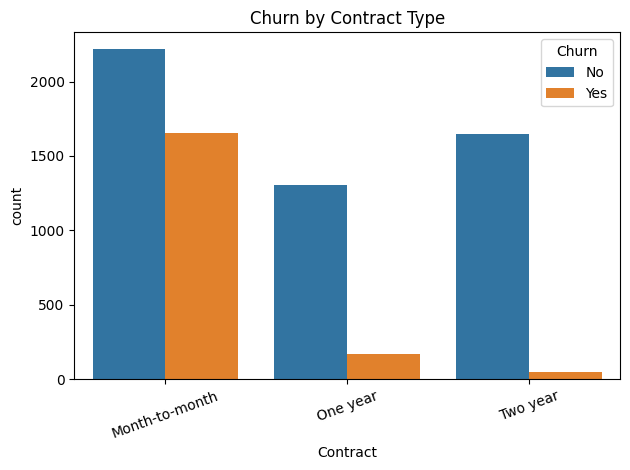

In [14]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Insight

Customers with month-to-month contracts exhibit the highest churn rate, while longer-term contracts (one or two years) show better retention. This indicates that contract duration is a strong predictor of customer loyalty.


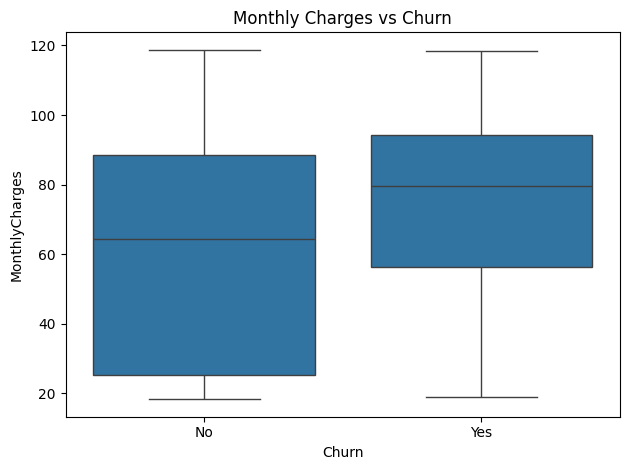

In [15]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.tight_layout()
plt.show()


### Insight

There is a clear tendency for churned customers to have higher monthly charges. This indicates that pricing may be a key factor influencing customer retention and churn behavior.


## Machine Learning (Pipeline)

This section trains a logistic regression model using a reproducible scikit-learn `Pipeline` that handles preprocessing (scaling numeric columns + one-hot encoding categorical columns) without manual feature engineering steps.


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Prepare data (match src/analysis.py)
data = df.drop(columns=["customerID"]).copy()

data["Churn"] = data["Churn"].map({"No": 0, "Yes": 1})
if data["Churn"].isna().any():
    bad = sorted(set(df["Churn"].dropna().unique()) - {"No", "Yes"})
    raise ValueError(f"Unexpected Churn values: {bad}")

X = data.drop(columns=["Churn"])
y = data["Churn"].astype(int)

cat_cols = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop",
)

clf = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=2000)),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.7998580553584103

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

